In [15]:
import pandas as pd
import numpy as np
import glob
import os
import matplotlib.pyplot as plt
import missingno as msno

In [3]:
data_path = '/Users/danielcai/Downloads/IDXExchange Data Science roles/_/crmls'
all_files = glob.glob(os.path.join(data_path, "CRMLSSold*.csv"))
selected_files = (f for f in all_files if '_filled' in f and [ '2025' in f or '202412' in f or '202411' in f or '202410' in f or '202409' in f or '202408' in f or '202407' in f or '202406' in f])
# to merge all the files into a single DataFrame
df = pd.concat((pd.read_csv(f, low_memory= False) for f in selected_files), ignore_index=True)
## filtering:
df = df[df['PropertyType'].str.lower() == 'residential']
df = df[df['PropertySubType'].str.lower() == 'singlefamilyresidence']

print(df.shape)
print(df.head())

(398782, 82)
     Flooring ViewYN WaterfrontYN BasementYN PoolPrivateYN  OriginalListPrice  \
2         NaN   True          NaN        NaN         False           265000.0   
7         NaN   True          NaN        NaN         False           429000.0   
12        NaN   True          NaN        NaN         False           600000.0   
25        NaN  False          NaN        NaN         False           600000.0   
27  Tile,Wood    NaN          NaN        NaN         False           899999.0   

    ListingKey                 ListAgentEmail   CloseDate  ClosePrice  ...  \
2    543251400  michaelg@londonproperties.com  2024-04-02    250000.0  ...   
7    519252621              robynsong@aol.com  2024-04-30    413700.0  ...   
12   492708527    maryvillamarhomes@gmail.com  2024-04-03    725000.0  ...   
25  1073316150         jeff@whittingtonre.com  2024-04-12    600000.0  ...   
27  1073301375        leilasantos@compass.com  2024-04-10   1810000.0  ...   

   GarageSpaces    HighSchoolDi

In [4]:
# Check correlation between ListPrice and ClosePrice
print(df[['ListPrice', 'ClosePrice']].corr())

# Check how many rows have ListPrice missing
print(f"ListPrice missing: {df['ListPrice'].isnull().sum()}")
print(f"ClosePrice missing: {df['ClosePrice'].isnull().sum()}")

# Drop ListPrice to avoid data leakage
df = df.drop(columns=['ListPrice'], errors='ignore')

            ListPrice  ClosePrice
ListPrice    1.000000    0.973673
ClosePrice   0.973673    1.000000
ListPrice missing: 0
ClosePrice missing: 5


In [5]:
print (df.columns)
# since closedprice and listedprice are similar, we should be able to drop one of them.
# From the exploration notebook, we already have a list of dropped variables

cols_to_drop = [
    # Personal identifiers
    'ListAgentEmail', 'ListAgentFirstName', 'ListAgentLastName',
    'BuyerAgentFirstName', 'BuyerAgentLastName', 'BuyerAgentMlsId',
    'CoListAgentFirstName', 'CoListAgentLastName',
    'ListAgentFullName', 'CoListAgentLastName',
    
    # Constant state fields
    'StateOrProvince',
    
    # Redundant address
    'UnparsedAddress',
    
    # Above/Below grade (mostly empty in CA)
    'AboveGradeFinishedArea',
    
    # Brokerage names
    'ListOfficeName', 'BuyerOfficeName', 'CoListOfficeName',

    # redundant price field
    'listprice',
]
df = df.drop(columns=cols_to_drop, errors='ignore')
print(f"Columns remaining: {df.shape[1]}")


Index(['Flooring', 'ViewYN', 'WaterfrontYN', 'BasementYN', 'PoolPrivateYN',
       'OriginalListPrice', 'ListingKey', 'ListAgentEmail', 'CloseDate',
       'ClosePrice', 'ListAgentFirstName', 'ListAgentLastName', 'Latitude',
       'Longitude', 'UnparsedAddress', 'PropertyType', 'LivingArea',
       'DaysOnMarket', 'ListOfficeName', 'BuyerOfficeName', 'CoListOfficeName',
       'ListAgentFullName', 'CoListAgentFirstName', 'CoListAgentLastName',
       'BuyerAgentMlsId', 'BuyerAgentFirstName', 'BuyerAgentLastName',
       'FireplacesTotal', 'AssociationFeeFrequency', 'AboveGradeFinishedArea',
       'ListingKeyNumeric', 'MLSAreaMajor', 'TaxAnnualAmount',
       'CountyOrParish', 'MlsStatus', 'ElementarySchool', 'AttachedGarageYN',
       'ParkingTotal', 'BuilderName', 'PropertySubType', 'LotSizeAcres',
       'SubdivisionName', 'BuyerOfficeAOR', 'YearBuilt',
       'BuyerAgencyCompensationType', 'StreetNumberNumeric', 'ListingId',
       'BathroomsTotalInteger', 'City', 'BuyerAgencyComp

Flooring                        143282
ViewYN                           62977
WaterfrontYN                    398590
BasementYN                      389237
PoolPrivateYN                    46365
OriginalListPrice                  407
ClosePrice                           5
Latitude                           305
Longitude                          305
LivingArea                         268
FireplacesTotal                 398782
AssociationFeeFrequency         302421
MLSAreaMajor                     56968
TaxAnnualAmount                 398782
ElementarySchool                342261
AttachedGarageYN                 43908
ParkingTotal                      8325
BuilderName                     379484
LotSizeAcres                      7188
SubdivisionName                 261323
BuyerOfficeAOR                   16637
YearBuilt                          383
BuyerAgencyCompensationType      47926
StreetNumberNumeric               9993
BathroomsTotalInteger              126
City                     

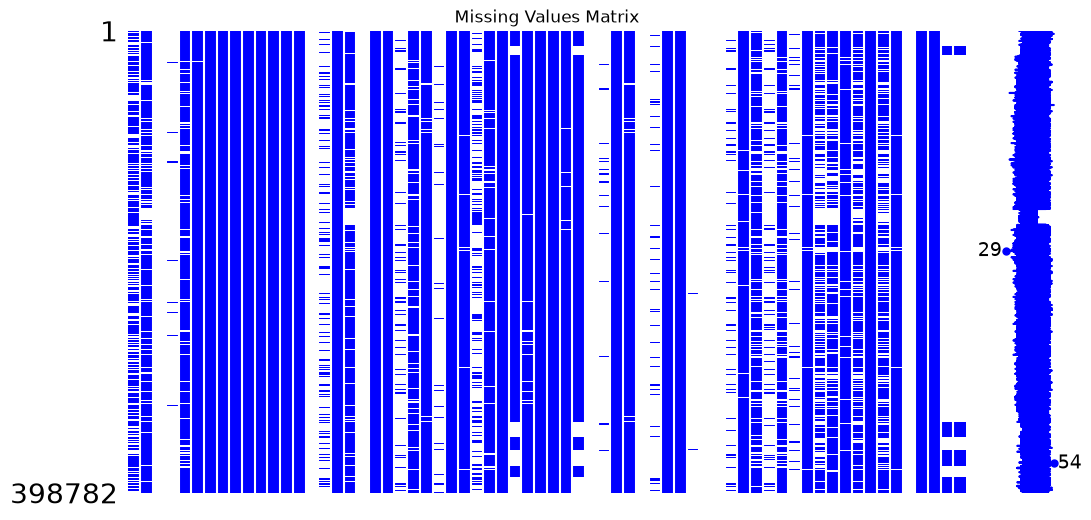

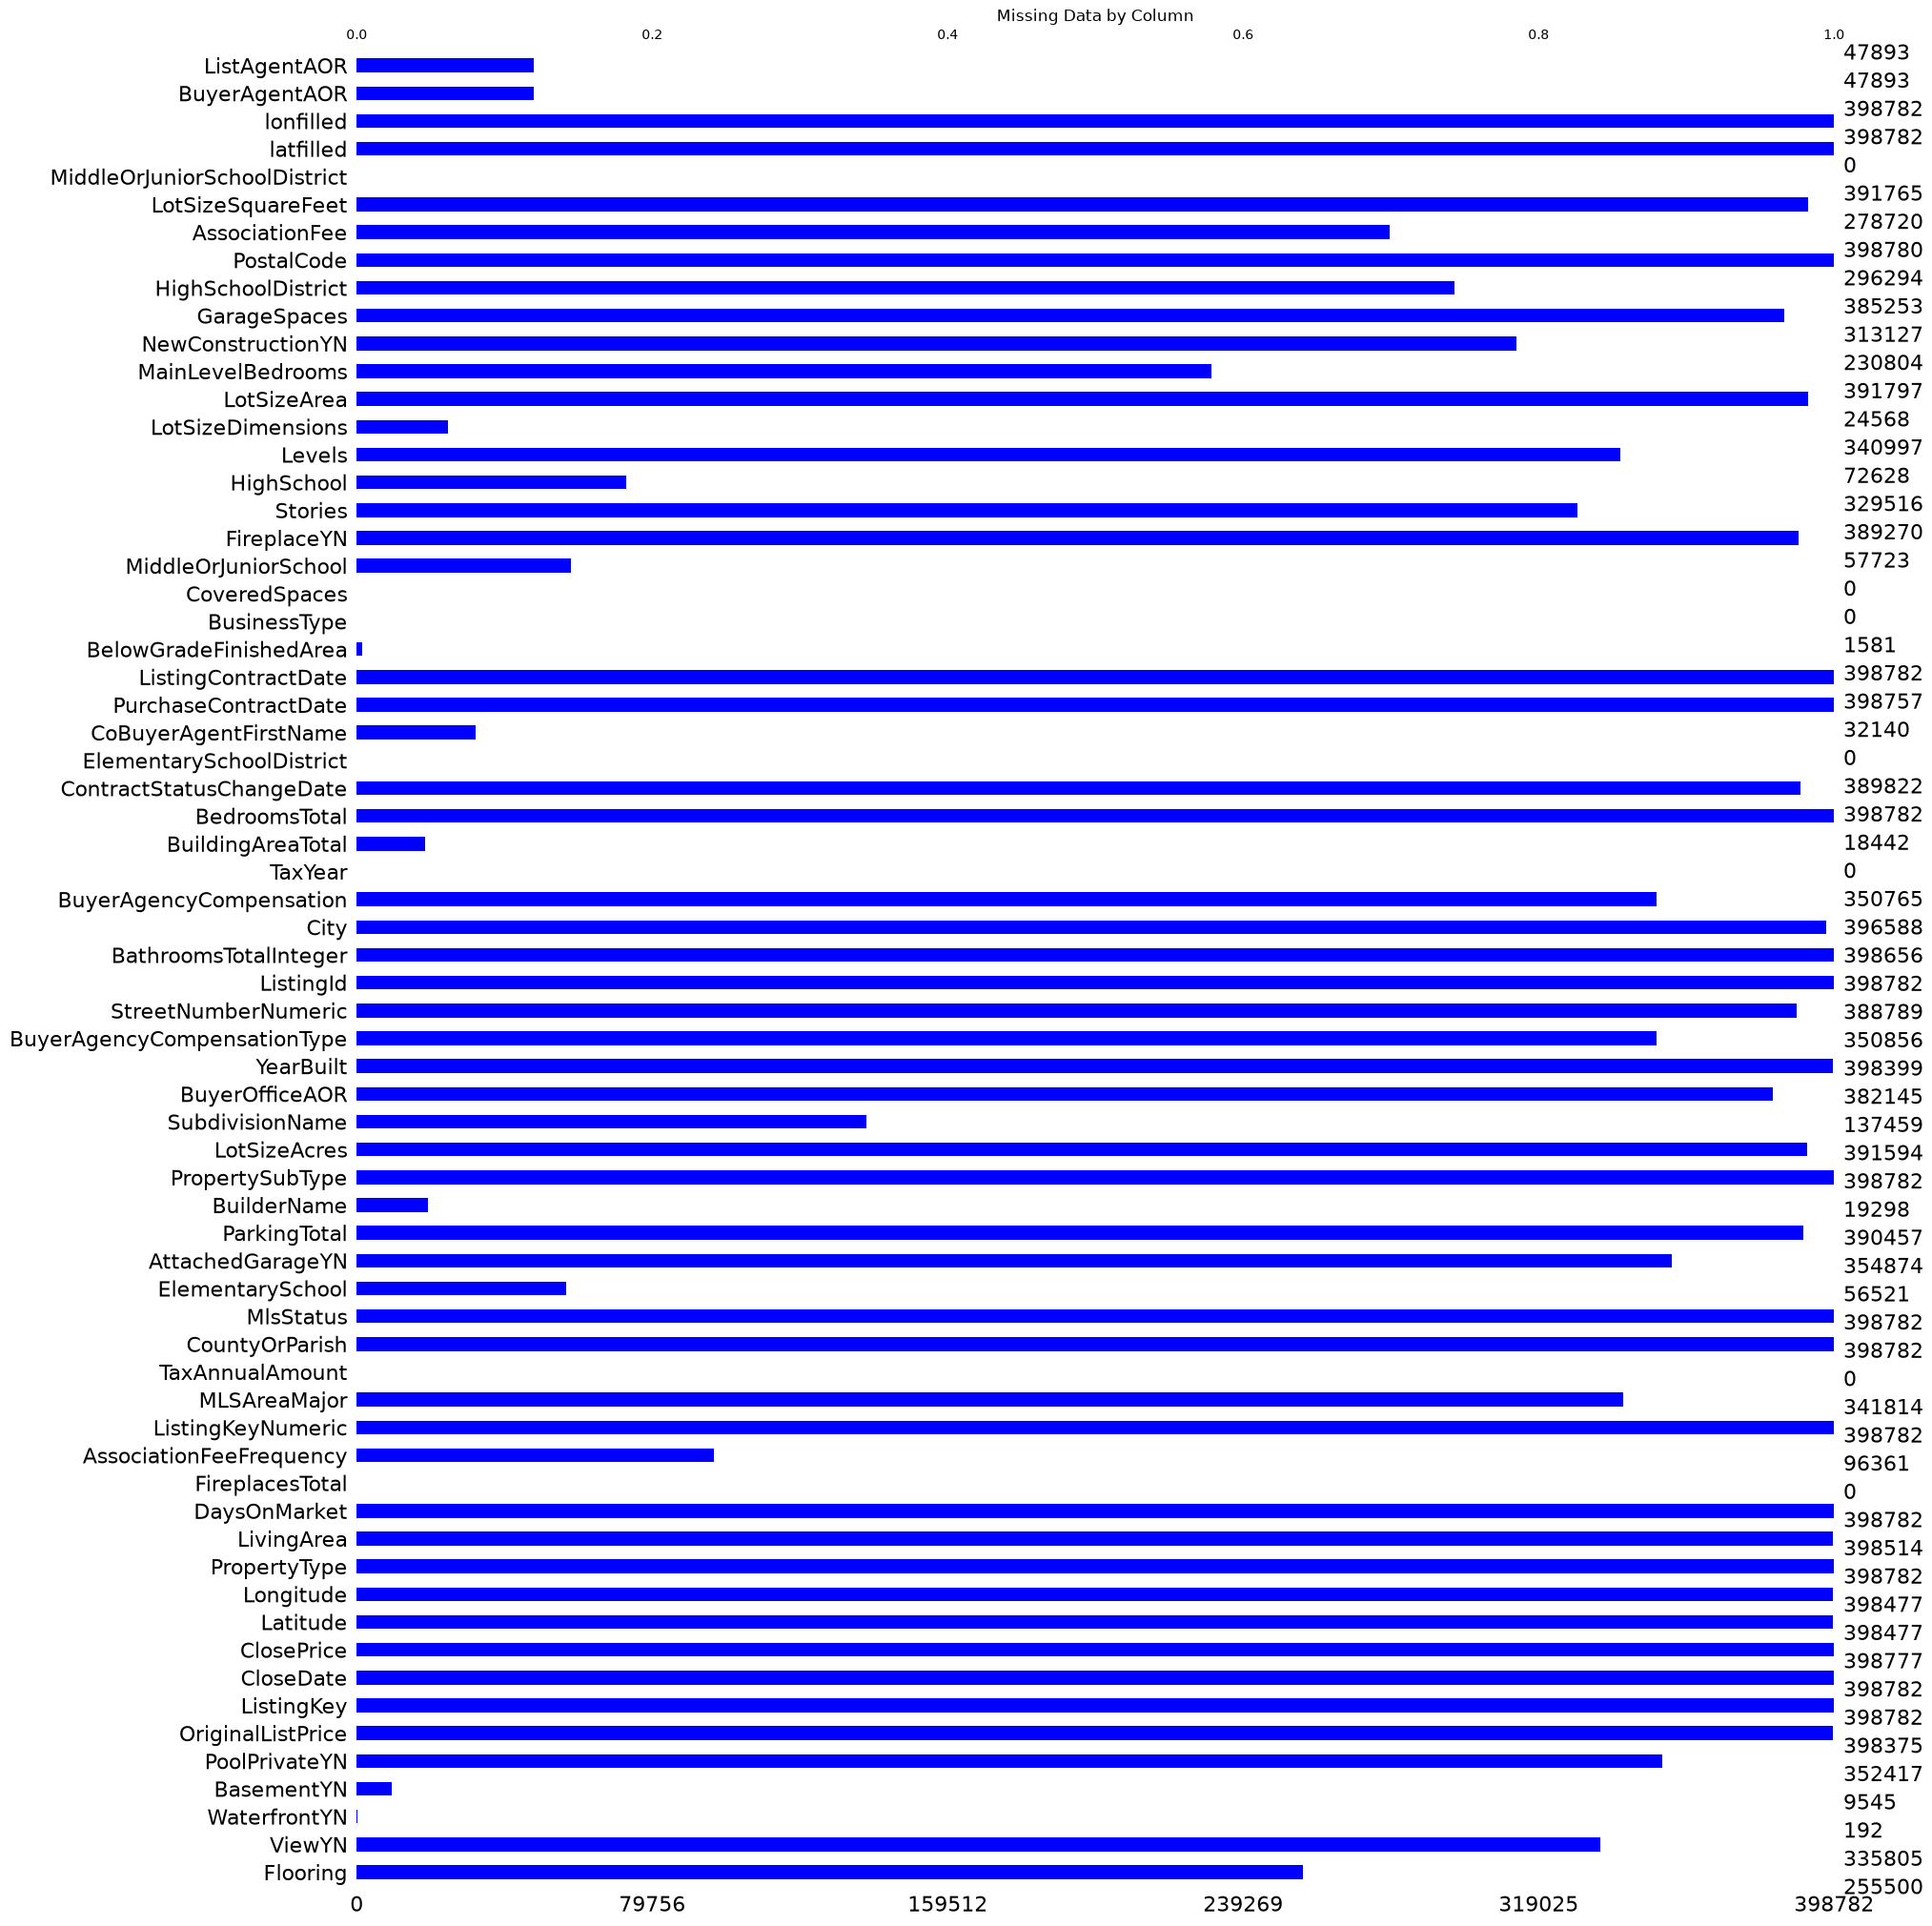

Columns remaining: 45
Remaining missing: 525378


In [20]:
# checking any missing values in the remaining columns
missing_values = df.isnull().sum()
print(missing_values[missing_values > 0])
missing_pct = (missing_values / len(df) * 100).round(2)
missing_df = pd.DataFrame({'missing_count': missing_values, 'missing_pct': missing_pct})
missing_df = missing_df[missing_df['missing_count'] > 0].sort_values('missing_pct', ascending=False)
print(missing_df)

#Visualize missing values

msno.matrix(df, figsize=(12, 6), color = (0, 0, 1))
plt.title('Missing Values Matrix')
plt.show()


msno.bar(df, figsize=(20, 25 ), color = (0,0,1))
plt.title('Missing Data by Column')
plt.show()

#based on the missing values analysis, we can drop columns that are almost completely missing.
drop_100 = [
    'BusinessType',              # 100% — irrelevant for residential
    'ElementarySchoolDistrict',  # 100% — already have HighSchoolDistrict
    'MiddleOrJuniorSchoolDistrict', # 100% — completely empty
    'FireplacesTotal',           # 100% — completely empty
    'TaxYear',                   # 100% — completely empty
    'CoveredSpaces',             # 100% — flagged for review in your doc
    'TaxAnnualAmount',           # 100% — completely empty
]

drop_high_missing = [
    'WaterfrontYN',              # 99.95% — nearly all missing
    'BelowGradeFinishedArea',    # 99.60% — rare in CA
    'BasementYN',                # 97.61% — rare in CA
    'BuildingAreaTotal',         # 95.38% — redundant with LivingArea
    'BuilderName',               # 95.16% — extract signal first
    'LotSizeDimensions',         # 93.84% — string format, redundant
    'CoBuyerAgentFirstName',     # 91.94% — personal identifier
    'ListAgentAOR',              # 87.99% — low signal
    'BuyerAgentAOR',             # 87.99% — low signal
    'ElementarySchool',          # 85.83% — high cardinality string
    'MiddleOrJuniorSchool',      # 85.53% — high cardinality string
    'HighSchool',                # 81.79% — high cardinality string
]

drop_borderline = [
    'AssociationFeeFrequency',   # 75.84% — redundant with AssociationFee
    'SubdivisionName',           # 65.53% — high cardinality string
    'Flooring',                  # 35.93% — too vague to encode reliably
]

fill_zero = [
    'MainLevelBedrooms',   # 42.12% — missing = no main level bedrooms
    'AssociationFee',      # 30.11% — missing = no HOA
    'NewConstructionYN',   # 21.48% — missing = not new construction
]

all_drops = (
    drop_100 + 
    drop_high_missing + 
    drop_borderline
)

# Extract BuilderName signal before dropping
df['IsNewConstruction'] = (
    df['BuilderName'].notna() | 
    (df['NewConstructionYN'] == 1)
).astype(int)

df = df.drop(columns=all_drops, errors='ignore')

# Impute remaining
fill_zero = ['MainLevelBedrooms', 'AssociationFee', 'NewConstructionYN']
for col in fill_zero:
    if col in df.columns:
        df[col] = df[col].fillna(0)

df['HighSchoolDistrict'] = df['HighSchoolDistrict'].fillna('Unknown')

print(f"Columns remaining: {df.shape[1]}")
print(f"Remaining missing: {df.isnull().sum().sum()}")



In [21]:
#Train/test split

df['CloseDate'] = pd.to_datetime(df['CloseDate'])

# Check what months you have
print(df['CloseDate'].dt.to_period('M').value_counts().sort_index())
print(f"\nEarliest: {df['CloseDate'].min()}")
print(f"Latest: {df['CloseDate'].max()}")

# Identify the most recent month
latest_month = df['CloseDate'].dt.to_period('M').max()
print(f"Test month: {latest_month}")

# Split
test_df = df[df['CloseDate'].dt.to_period('M') == latest_month]
train_df = df[df['CloseDate'].dt.to_period('M') != latest_month]

print(f"Train size: {train_df.shape}")
print(f"Test size: {test_df.shape}")
print(f"Test %: {len(test_df)/len(df)*100:.1f}%")

# Drop columns not used as features
drop_from_features = [
    'CloseDate',
    'ClosePrice',        # target variable
    'ListingContractDate',
    'PurchaseContractDate',
    'ContractStatusChangeDate',
]

feature_cols = [col for col in df.columns if col not in drop_from_features]

X_train = train_df[feature_cols]
y_train = train_df['ClosePrice']

X_test = test_df[feature_cols]
y_test = test_df['ClosePrice']

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

# Before dropping CloseDate, extract time signals
df['close_month'] = df['CloseDate'].dt.month
df['close_quarter'] = df['CloseDate'].dt.quarter
df['close_year'] = df['CloseDate'].dt.year

# Make sure test dates are all after train dates
print(f"Latest train date: {train_df['CloseDate'].max()}")
print(f"Earliest test date: {test_df['CloseDate'].min()}")



CloseDate
2022-01    13014
2022-02    12941
2022-03    18621
2022-04    18155
2022-05    17509
2022-06    16931
2022-07    13773
2022-08    14951
2022-09    14328
2022-10    12087
2022-11    10425
2022-12    10257
2023-01     8003
2023-02     8830
2023-03    12633
2023-04    11348
2023-05    13712
2023-06    13890
2023-07    11864
2023-08    12958
2023-09    11355
2023-10    11438
2023-11     9902
2023-12     9694
2024-01     8322
2024-02     9564
2024-03    11634
2024-04    12745
2024-05    13831
2024-06    12545
2024-07    13378
2025-01     8144
Freq: M, Name: count, dtype: int64

Earliest: 2022-01-01 00:00:00
Latest: 2025-01-31 00:00:00
Test month: 2025-01
Train size: (390638, 45)
Test size: (8144, 45)
Test %: 2.0%
X_train shape: (390638, 40)
X_test shape: (8144, 40)
y_train shape: (390638,)
y_test shape: (8144,)
Latest train date: 2024-07-31 00:00:00
Earliest test date: 2025-01-01 00:00:00
